In [24]:
import pandas as pd
import numpy as np
import ast
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, mean_squared_error,
                               classification_report, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb

In [46]:
pd.set_option("display.max_columns", None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [47]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(".")))
from DB_pipeline.drive_auth_setup import get_drive_csv_as_df
df_hotel_reviews = get_drive_csv_as_df()

In [48]:
print("Shape:", df_hotel_reviews.shape)
print("\nNull counts:\n", df_hotel_reviews.isnull().sum())
print("\nDuplicate rows:", df_hotel_reviews.duplicated().sum())
print("\nDtypes:\n", df_hotel_reviews.dtypes)

Shape: (515738, 17)

Null counts:
 Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64

Duplicate rows: 526

Dtypes:
 Hotel_Address                                     str


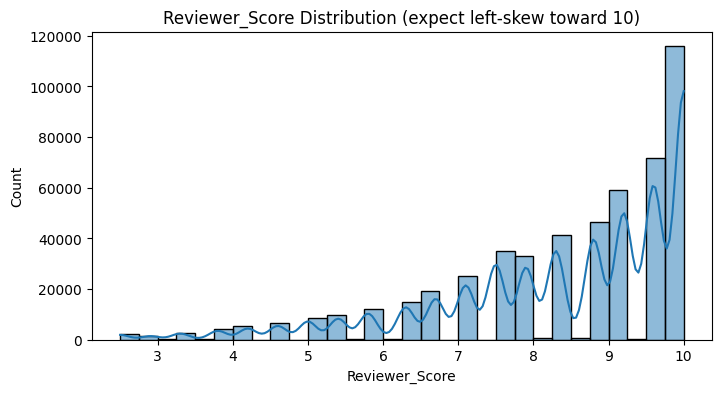

In [49]:
plt.figure(figsize=(8, 4))
sns.histplot(df_hotel_reviews['Reviewer_Score'], bins=30, kde=True)
plt.title("Reviewer_Score Distribution (expect left-skew toward 10)")
plt.savefig("eda_score_distribution.png")
plt.show()
plt.close()

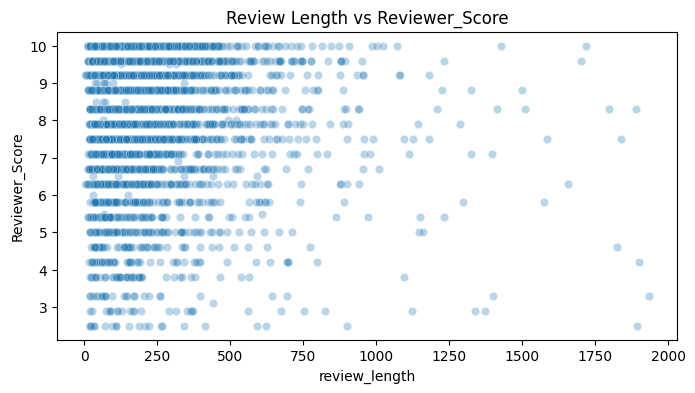

In [50]:
# Review length vs score
df_hotel_reviews['review_length'] = (df_hotel_reviews['Positive_Review'].fillna('').str.len() +
                        df_hotel_reviews['Negative_Review'].fillna('').str.len())
plt.figure(figsize=(8, 4))
sns.scatterplot(x='review_length', y='Reviewer_Score', data=df_hotel_reviews.sample(5000), alpha=0.3)
plt.title("Review Length vs Reviewer_Score")
plt.savefig("eda_length_vs_score.png")
plt.show()
plt.close()

In [51]:
# Top nationalities
print("\nTop 10 Reviewer Nationalities:\n", df_hotel_reviews['Reviewer_Nationality'].value_counts().head(10))
# Top hotels by review count
print("\nTop 10 Hotels by review count:\n", df_hotel_reviews['Hotel_Name'].value_counts().head(10))
# Average_Score vs Reviewer_Score correlation
corr = df_hotel_reviews[['Average_Score', 'Reviewer_Score']].corr()
print("\nAverage_Score vs Reviewer_Score correlation:\n", corr)
# Missing text check
print("\n'No Positive' count:", (df_hotel_reviews['Positive_Review'].str.strip() == 'No Positive').sum())
print("'No Negative' count:", (df_hotel_reviews['Negative_Review'].str.strip() == 'No Negative').sum())


Top 10 Reviewer Nationalities:
 Reviewer_Nationality
United Kingdom               245246
United States of America      35437
Australia                     21686
Ireland                       14827
United Arab Emirates          10235
Saudi Arabia                   8951
Netherlands                    8772
Switzerland                    8678
Germany                        7941
Canada                         7894
Name: count, dtype: int64

Top 10 Hotels by review count:
 Hotel_Name
Britannia International Hotel Canary Wharf           4789
Strand Palace Hotel                                  4256
Park Plaza Westminster Bridge London                 4169
Copthorne Tara Hotel London Kensington               3578
DoubleTree by Hilton Hotel London Tower of London    3212
Grand Royale London Hyde Park                        2958
Holiday Inn London Kensington                        2768
Hilton London Metropole                              2628
Millennium Gloucester Hotel London                  

In [52]:
df = df_hotel_reviews.drop_duplicates()
len(df)

515212

In [53]:
# Fix using explicit .loc assignment
df.loc[:, 'Positive_Review'] = df['Positive_Review'].replace('No Positive', '')
df.loc[:, 'Negative_Review'] = df['Negative_Review'].replace('No Negative', '')

df.loc[:, 'full_review_text'] = (
    (df['Positive_Review'] + " " + df['Negative_Review'])
    .astype(str)
    .str.lower()
    .str.replace(r'[^a-z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
df['full_review_text'].head(2)

# df['Positive_Review'] = df['Positive_Review'].replace('No Positive', '')
# df['Negative_Review'] = df['Negative_Review'].replace('No Negative', '')
# df['full_review_text'] = (
#     (df['Positive_Review'] + " " + df['Negative_Review'])
#     .astype(str)
#     .str.lower()
#     .str.replace(r'[^a-z\s]', ' ', regex=True)
#     .str.replace(r'\s+', ' ', regex=True)
#     .str.strip()
# )
# df['full_review_text'].head(2)

0    only the park outside of the hotel was beautif...
1    no real complaints the hotel was great great l...
Name: full_review_text, dtype: str

In [54]:
def parse_tags(tag_str):
    try:
        tags = [t.strip() for t in ast.literal_eval(tag_str)]
    except Exception:
        tags = []
    trip_type = next((t for t in tags if 'trip' in t.lower()), None)
    room_type = next((t for t in tags if 'Room' in t or 'Suite' in t), None)
    length_of_stay = next((t for t in tags if 'Stayed' in t), None)
    return pd.Series([trip_type, room_type, length_of_stay])
df[['trip_type', 'room_type', 'length_of_stay']] = df['Tags'].apply(parse_tags)

In [55]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng', 'review_length', 'full_review_text',
       'trip_type', 'room_type', 'length_of_stay'],
      dtype='str')

In [56]:
df.drop(columns=['Tags'], inplace=True)

In [57]:
df['score_bucket'] = df['Reviewer_Score'].apply(lambda x: 0 if x <= 7 else 1)
# else ('Medium' if x <= 8 else 'High')
# else 'Good'

In [58]:
top_nationalities = df['Reviewer_Nationality'].value_counts().nlargest(22).index
print(top_nationalities)
df['nationality_grouped'] = df['Reviewer_Nationality'].where(
        df['Reviewer_Nationality'].isin(top_nationalities), 'Other'
    )
df['nationality_grouped'].unique()

Index([' United Kingdom ', ' United States of America ', ' Australia ',
       ' Ireland ', ' United Arab Emirates ', ' Saudi Arabia ',
       ' Netherlands ', ' Switzerland ', ' Germany ', ' Canada ', ' France ',
       ' Israel ', ' Italy ', ' Belgium ', ' Turkey ', ' Kuwait ', ' Spain ',
       ' Romania ', ' Russia ', ' South Africa ', ' India ', ' Greece '],
      dtype='str', name='Reviewer_Nationality')


<ArrowStringArray>
[                  ' Russia ',                  ' Ireland ',
                ' Australia ',           ' United Kingdom ',
                      'Other',                  ' Belgium ',
                   ' France ',                    ' Italy ',
                   ' Canada ',              ' Netherlands ',
                  ' Germany ', ' United States of America ',
                   ' Israel ',              ' Switzerland ',
                    ' India ',     ' United Arab Emirates ',
             ' South Africa ',                    ' Spain ',
                   ' Turkey ',             ' Saudi Arabia ',
                  ' Romania ',                   ' Greece ',
                   ' Kuwait ']
Length: 23, dtype: str

In [59]:
print(df['nationality_grouped'].value_counts())

nationality_grouped
 United Kingdom               245110
Other                          85697
 United States of America      35349
 Australia                     21648
 Ireland                       14814
 United Arab Emirates          10229
 Saudi Arabia                   8940
 Netherlands                    8757
 Switzerland                    8669
 Germany                        7929
 Canada                         7883
 France                         7265
 Israel                         6601
 Italy                          6113
 Belgium                        6024
 Turkey                         5440
 Kuwait                         4915
 Spain                          4735
 Romania                        4548
 Russia                         3898
 South Africa                   3816
 India                          3432
 Greece                         3400
Name: count, dtype: int64


In [60]:
cat_cols = ['nationality_grouped', 'trip_type', 'room_type', 'length_of_stay']
encoders = {}
for col in cat_cols:
  le = LabelEncoder()
  df[col + '_enc'] = le.fit_transform(df[col].astype(str))
  encoders[col] = le
# Drop rows with empty combined text after cleaning
df = df[df['full_review_text'].str.strip() != ''].reset_index(drop=True)

print("\nPost-preprocessing shape:", df.shape)
print(df['score_bucket'].value_counts())


Post-preprocessing shape: (514968, 27)
score_bucket
1    427879
0     87089
Name: count, dtype: int64


In [61]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score',
       'days_since_review', 'lat', 'lng', 'review_length', 'full_review_text',
       'trip_type', 'room_type', 'length_of_stay', 'score_bucket',
       'nationality_grouped', 'nationality_grouped_enc', 'trip_type_enc',
       'room_type_enc', 'length_of_stay_enc'],
      dtype='str')

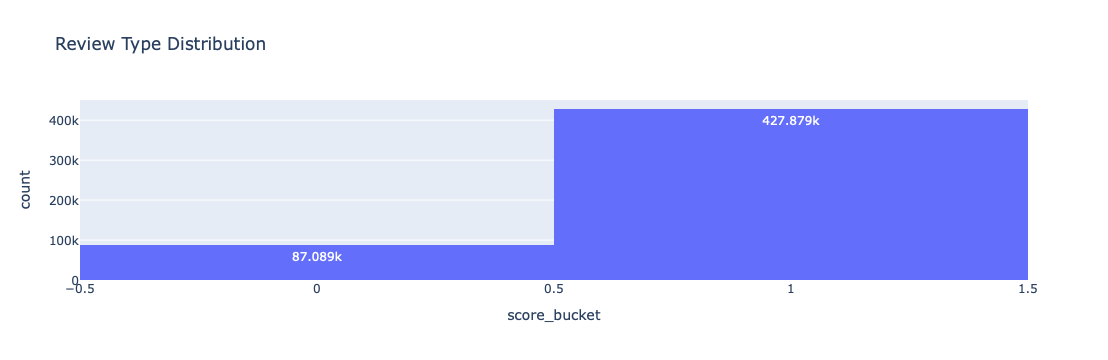

In [62]:
import plotly.express as px

fig = px.histogram(df, x="score_bucket", title='Review Type Distribution', text_auto=True)
fig.show()

In [63]:
tfidf = TfidfVectorizer(min_df=5,                  # Rejects rare words/typos appearing < 5 times
    max_df=0.7,                # Drops corpus-specific stop words (appearing in >70% of reviews)
    max_features=25000,        # Caps the vocabulary to the top 50k most predictive signals

    # 2. Tokenization & Cleaning
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\b[A-Za-z]{2,}\b',  # Eliminates standalone numbers and 1-letter noise
    ngram_range=(1, 2),        # Switches to unigrams+bigrams (trigrams add noise here)
    stop_words='english',      # Removes generic english stop words

    # 3. Weighting Adjustments
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True)
# tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), stop_words='english')
X_text = tfidf.fit_transform(df['full_review_text'])
X_text.shape

(514968, 25000)

In [64]:
struct_cols = ['nationality_grouped_enc', 'trip_type_enc', 'room_type_enc',
                   'length_of_stay_enc', 'Average_Score', 'Total_Number_of_Reviews',
                   'Total_Number_of_Reviews_Reviewer_Has_Given']
X_struct = df[struct_cols].fillna(0)
scaler = StandardScaler()
X_struct_scaled = scaler.fit_transform(X_struct)
X_struct_scaled.shape

(514968, 7)

In [65]:
# target_mapping = {'bad': 0, 'good': 1}
y_class = df['score_bucket']
y_reg = df['Reviewer_Score']

In [66]:
def split_data(X, y, test_size=0.15, val_size=0.15, stratify=None):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), random_state=42, stratify=stratify
    )
    strat_temp = y_temp if stratify is not None else None
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=strat_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test
# Split on text features for classification
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X_text, y_class, stratify=y_class
)

# Logistic Regression

In [67]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1),
    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: Logistic Regression


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression -> Accuracy: 0.8836, Macro F1: 0.7602

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8309, Macro F1: 0.4556

=== FINAL MODEL COMPARISON TABLE ===
              Model  Accuracy  Macro_F1
Logistic Regression  0.883643  0.760169
   KNN (subsampled)  0.830863  0.455624


In [69]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "Naive Bayes": MultinomialNB(),
    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: Naive Bayes
Naive Bayes -> Accuracy: 0.8763, Macro F1: 0.7446

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8310, Macro F1: 0.4564

=== FINAL MODEL COMPARISON TABLE ===
           Model  Accuracy  Macro_F1
     Naive Bayes  0.876342  0.744571
KNN (subsampled)  0.831018  0.456425


In [70]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42),
    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: Decision Tree
Decision Tree -> Accuracy: 0.8473, Macro F1: 0.6425

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8308, Macro F1: 0.4559

=== FINAL MODEL COMPARISON TABLE ===
           Model  Accuracy  Macro_F1
   Decision Tree  0.847343  0.642505
KNN (subsampled)  0.830759  0.455893


In [71]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "Linear SVM": LinearSVC(max_iter=2000),
    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: Linear SVM
Linear SVM -> Accuracy: 0.8790, Macro F1: 0.7564

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8309, Macro F1: 0.4555

=== FINAL MODEL COMPARISON TABLE ===
           Model  Accuracy  Macro_F1
      Linear SVM  0.878995  0.756405
KNN (subsampled)  0.830876  0.455477


In [72]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "XGBoost": xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                                       eval_metric='mlogloss', n_jobs=-1, random_state=42),
    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: XGBoost


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:07:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost -> Accuracy: 0.8762, Macro F1: 0.7283

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8310, Macro F1: 0.4566

=== FINAL MODEL COMPARISON TABLE ===
           Model  Accuracy  Macro_F1
         XGBoost  0.876238  0.728297
KNN (subsampled)  0.830979  0.456563


In [73]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "LightGBM": lgb.LGBMClassifier(n_estimators=200, n_jobs=-1, random_state=42),    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: LightGBM
[LightGBM] [Info] Number of positive: 299515, number of negative: 60962
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 5.027897 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 846832
[LightGBM] [Info] Number of data points in the train set: 360477, number of used features: 24981
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.830885 -> initscore=1.591914
[LightGBM] [Info] Start training from score 1.591914
LightGBM -> Accuracy: 0.8782, Macro F1: 0.7393

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8304, Macro F1: 0.4575

=== FINAL MODEL COMPARISON TABLE ===
           Model  Accuracy  Macro_F1
        LightGBM  0.878180  0.739282
KNN (subsampled)  0.830436  0.457512


In [74]:
def train_all_models(X_train, y_train, X_val, y_val):
    results = []

    models = {
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    }

    # KNN on a subsample only (slow on 500K rows)
    if X_train.shape[0] > 50000:
        idx = np.random.choice(X_train.shape[0], 50000, replace=False)
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train[idx], y_train.iloc[idx])
    else:
        knn_model = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
        knn_model.fit(X_train, y_train)
    models["KNN (subsampled)"] = knn_model

    for name, model in models.items():
        print(f"\nTraining: {name}")
        if name != "KNN (subsampled)":
            model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='macro')
        results.append({"Model": name, "Accuracy": acc, "Macro_F1": f1})
        print(f"{name} -> Accuracy: {acc:.4f}, Macro F1: {f1:.4f}")

    results_df = pd.DataFrame(results).sort_values("Macro_F1", ascending=False)
    return results_df, models
results_df, trained_models = train_all_models(X_train, y_train, X_val, y_val)
print("\n=== FINAL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
#results_df.to_csv("ml_model_comparison.csv", index=False)


Training: Gradient Boosting
Gradient Boosting -> Accuracy: 0.8551, Macro F1: 0.6108

Training: KNN (subsampled)
KNN (subsampled) -> Accuracy: 0.8304, Macro F1: 0.4578

=== FINAL MODEL COMPARISON TABLE ===
            Model  Accuracy  Macro_F1
Gradient Boosting  0.855123  0.610802
 KNN (subsampled)  0.830423  0.457806


In [ ]:
df.columns

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score',
       'days_since_review', 'lat', 'lng', 'review_length', 'full_review_text',
       'trip_type', 'room_type', 'length_of_stay', 'score_bucket',
       'nationality_grouped', 'nationality_grouped_enc', 'trip_type_enc',
       'room_type_enc', 'length_of_stay_enc'],
      dtype='str')